# Tugas 8 Clustering Web dengan Fuzzy C-Means|

Rafly Faldiansyah Putra

21041100063

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import re
import numpy as np
from IPython.display import display, Markdown
import skfuzzy as fuzz
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
# 1. Membaca Dataset
# Membaca file CSV yang berisi dataset
df = pd.read_csv("preprocessing-kompas.csv")

# Mengganti nilai NaN dengan string kosong agar tidak ada data kosong yang menyebabkan error
# df['stopword_removal'] = df['stopword_removal'].fillna('')

# 2. Mengonversi Data Teks ke TF-IDF
# Menginisialisasi TfidfVectorizer dengan normalisasi L2
vectorizer = TfidfVectorizer(norm='l2')

# Menghitung nilai TF-IDF untuk setiap dokumen
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])

# Mengubah hasil TF-IDF menjadi DataFrame untuk kemudahan akses
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# 3. Reduksi Dimensi dengan Truncated SVD
# Menginisialisasi TruncatedSVD untuk mereduksi dimensi menjadi 100 komponen (atau sesuai kebutuhan)
svd = TruncatedSVD(n_components=100, random_state=42)

# Mengaplikasikan SVD pada matriks TF-IDF untuk menghasilkan matriks dengan dimensi yang lebih rendah
svd_matrix = svd.fit_transform(tfidf_matrix)

# Menyimpan hasil SVD dalam DataFrame untuk digunakan dalam perhitungan kemiripan
svd_df = pd.DataFrame(svd_matrix)

# Menampilkan 10 baris pertama dari DataFrame hasil SVD
svd_df.head(1000)



,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.318048,0.336699,0.001047,0.008270,-0.257332,0.017326,0.159126,-0.324972,-0.082744,0.175946,...,0.025443,0.032022,0.003989,-0.084826,0.001480,0.006058,0.009300,0.029638,0.005525,0.003858
1,0.267889,0.265209,0.001206,-0.001144,-0.145906,0.051709,-0.002118,-0.098570,0.018178,-0.014501,...,-0.071177,-0.047667,-0.032383,0.038653,0.032659,0.012287,-0.018055,0.015435,0.003373,0.001066
2,0.275993,0.289724,0.009255,0.018454,-0.282478,0.025928,0.141696,-0.350281,-0.059327,0.174348,...,0.023016,0.017567,-0.023269,-0.001327,0.025918,-0.024781,0.000734,0.035208,-0.000262,0.001894
3,0.184904,-0.045614,-0.038867,0.105367,-0.001282,-0.128633,0.080001,0.046412,-0.074667,-0.001831,...,0.010405,-0.014090,-0.002174,-0.009361,-0.001838,-0.003785,0.006885,-0.008148,-0.002289,-0.001875
4,0.336624,0.377235,0.005007,-0.022246,-0.212861,0.020914,0.119120,-0.363587,-0.089158,0.186927,...,-0.040972,-0.035931,0.042560,0.074858,0.003522,0.046988,-0.006124,-0.046595,-0.007314,0.000503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.135096,-0.082512,0.057765,-0.012827,0.060773,0.104402,-0.004441,0.079390,0.519378,0.481841,...,-0.004262,-0.002475,-0.001884,-0.054075,-0.008057,-0.005671,-0.015422,-0.000973,0.020449,0.001359
96,0.136410,-0.027847,0.022742,0.016475,-0.004543,0.027487,0.100443,0.050808,0.128822,-0.046311,...,-0.022888,-0.001423,-0.003475,-0.012415,-0.011740,-0.006815,0.001626,0.000196,0.008629,-0.003298
97,0.089245,-0.069275,-0.004827,0.022257,0.011292,-0.018394,0.021997,0.033593,0.044537,-0.002819,...,0.009351,-0.002837,-0.000367,0.014356,0.008336,0.004960,-0.010100,0.001605,0.000423,-0.002849
98,0.127469,-0.039437,0.019895,-0.025436,0.002352,0.022569,-0.000966,0.033656,0.097731,0.022922,...,-0.039153,-0.026095,0.048038,0.021043,-0.016784,0.014634,0.006370,0.006212,0.004308,-0.006296


In [20]:
tfidf_df.head(1000)


,abcnetau,abdi,abdul,abi,academy,acara,acaraacara,ace,aceh,acep,...,zac,zaenuddin,zakiyuddin,zaman,zamannya,zamrud,zat,zulhas,zulkieflimansyahsuhaili,zulkifli
0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.058451,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.068032,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.000000,0.0,0.063166,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
import numpy as np
import skfuzzy as fuzz
from sklearn.metrics import accuracy_score

# 4. Menghapus Label Kategori dari Data untuk Clustering
# Misalkan kolom 'kategori' berisi label kategori asli, kita drop kolom tersebut untuk proses clustering
data_features = svd_df.drop(columns=['kategori'], errors='ignore')  # Buat pastikan kolom kategori memang ada

# 5. Proses Fuzzy C-Means Clustering
# Menentukan jumlah kluster (misalnya 2 kluster)
n_clusters = 2

# Menjalankan Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_features.T, n_clusters, m=2, error=0.05, maxiter=1000, init=None, seed=42
)

# Menentukan kluster akhir untuk setiap data berdasarkan derajat keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# 6. Mengukur Akurasi Clustering
# Misalkan kolom 'kategori' menyimpan label asli
if 'kategori' in df.columns:
    # Mengonversi label kategori ke bentuk numerik jika belum
    df['kategori_numerik'] = pd.factorize(df['kategori'])[0]
    
    # Menghitung akurasi dengan membandingkan hasil clustering dengan label asli
    akurasi = accuracy_score(df['kategori_numerik'], cluster_labels)
    print(f"Akurasi Clustering Fuzzy C-Means: {akurasi:.2f}")
else:
    print("Kolom 'kategori' tidak ditemukan pada dataset; akurasi tidak dapat dihitung.")


Akurasi Clustering Fuzzy C-Means: 0.73


,stopword_removal,kategori,cluster
0,jakarta kompascom aktris soraya larasati konsi...,Olahraga,0
1,jakarta kompascom olahraga gaya hidup masyarak...,Olahraga,0
2,jakarta kompascom olahraga kerap kali sulit or...,Olahraga,0
3,medan kompascom pasangan calon paslon wali kot...,Olahraga,1
4,jakarta kompascom aktris model soraya larasati...,Olahraga,0
...,...,...,...
95,kemenangan dikenang rakyat amerika kendali neg...,Politik,1
96,kupang kompascom serena cosgrova francis akrab...,Politik,1
97,kompascom pasangan calon gubernur cagub calon ...,Politik,1
98,ketegasan kerap melekat sosok presiden prabowo...,Politik,1


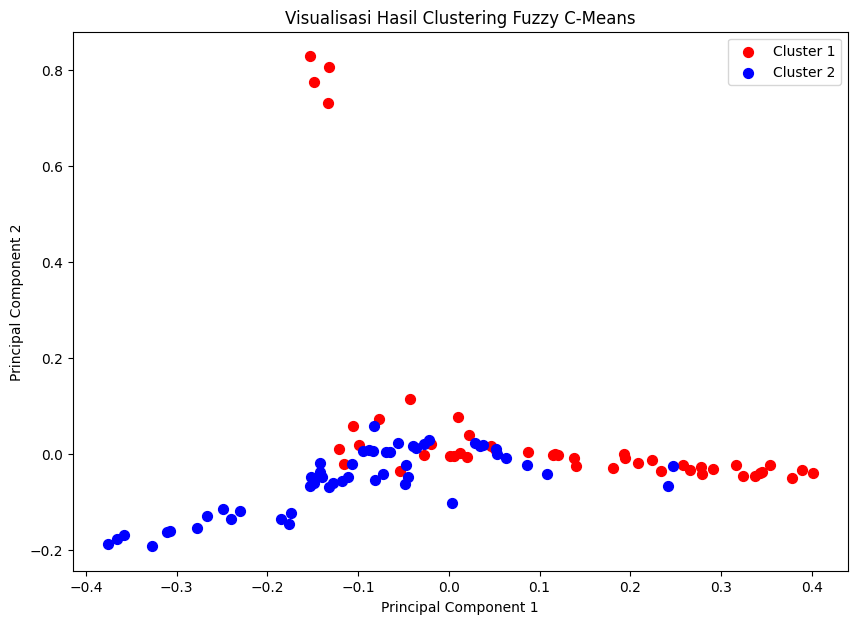

In [22]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
    
# 7. Menambahkan Kolom Kluster ke DataFrame
# Menyimpan hasil kluster di dalam DataFrame asli untuk memudahkan tampilan
df['cluster'] = cluster_labels

# Menampilkan beberapa dokumen beserta kluster mereka
display(df[['stopword_removal', 'kategori', 'cluster']].head(100))

# 8. Visualisasi Kluster
# Menggunakan PCA untuk mereduksi data ke dalam 2 dimensi agar bisa divisualisasikan
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_features)

# Mengonversi hasil PCA ke DataFrame untuk kemudahan visualisasi
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

# Plot hasil klustering
plt.figure(figsize=(10, 7))
colors = ['red', 'blue']  # Sesuaikan warna untuk setiap kluster

for cluster in range(n_clusters):
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], s=50, color=colors[cluster], label=f'Cluster {cluster + 1}')

# Menambahkan keterangan dan judul grafik
plt.title("Visualisasi Hasil Clustering Fuzzy C-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


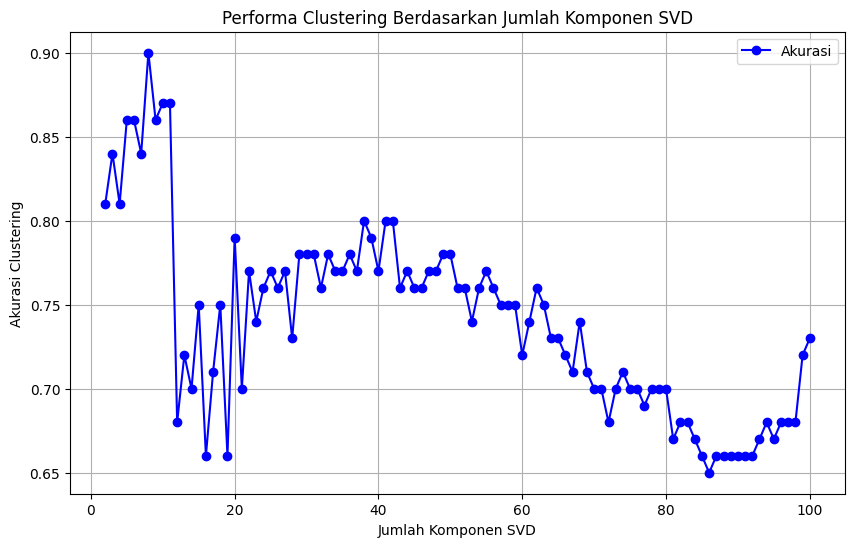

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import numpy as np

# 1. Membaca Dataset
df = pd.read_csv("preprocessing-kompas.csv")
df['stopword_removal'] = df['stopword_removal'].fillna('')

# 2. TF-IDF Vectorizer
vectorizer = TfidfVectorizer(norm='l2')
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])

# 3. Inisialisasi Akurasi untuk Plot
component_range = range(2, 101)  # Ubah sesuai rentang yang diinginkan
akurasi_list = []

# 4. Perulangan untuk Mengurangi Komponen
for n_components in component_range:
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    svd_matrix = svd.fit_transform(tfidf_matrix)

    data_features = pd.DataFrame(svd_matrix)

    # 5. Fuzzy C-Means Clustering
    n_clusters = 2
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_features.T, n_clusters, m=2, error=0.05, maxiter=1000, init=None, seed=42
    )
    cluster_labels = np.argmax(u, axis=0)

    # 6. Mengukur Akurasi (Jika Kategori Ada)
    if 'kategori' in df.columns:
        df['kategori_numerik'] = pd.factorize(df['kategori'])[0]
        akurasi = accuracy_score(df['kategori_numerik'], cluster_labels)
    else:
        akurasi = None  # Tidak ada pengukuran jika tidak ada label kategori

    akurasi_list.append(akurasi)

# 7. Plot Akurasi Berdasarkan Komponen
plt.figure(figsize=(10, 6))
plt.plot(component_range, akurasi_list, marker='o', color='b', label='Akurasi')
plt.title("Performa Clustering Berdasarkan Jumlah Komponen SVD")
plt.xlabel("Jumlah Komponen SVD")
plt.ylabel("Akurasi Clustering")
plt.grid(True)
plt.legend()
plt.show()


Terjadi kesalahan dengan 4917 fitur: array must not contain infs or NaNs
Terjadi kesalahan dengan 4717 fitur: array must not contain infs or NaNs
Fitur: 4517, Akurasi: 0.7300
Fitur: 4317, Akurasi: 0.7300
Fitur: 4117, Akurasi: 0.7300
Fitur: 3917, Akurasi: 0.7300
Fitur: 3717, Akurasi: 0.7300
Fitur: 3517, Akurasi: 0.7300
Fitur: 3317, Akurasi: 0.7300
Fitur: 3117, Akurasi: 0.7300
Fitur: 2917, Akurasi: 0.7300
Fitur: 2717, Akurasi: 0.7300
Fitur: 2517, Akurasi: 0.7300
Fitur: 2317, Akurasi: 0.7300
Fitur: 2117, Akurasi: 0.7300
Fitur: 1917, Akurasi: 0.7300
Fitur: 1717, Akurasi: 0.7300
Fitur: 1517, Akurasi: 0.7300
Fitur: 1317, Akurasi: 0.7300
Fitur: 1117, Akurasi: 0.7300
Fitur: 917, Akurasi: 0.7300
Fitur: 717, Akurasi: 0.7300
Fitur: 517, Akurasi: 0.7300
Fitur: 317, Akurasi: 0.7300
Fitur: 316, Akurasi: 0.7300
Fitur: 315, Akurasi: 0.7300
Fitur: 314, Akurasi: 0.7300
Fitur: 313, Akurasi: 0.7300
Fitur: 312, Akurasi: 0.7300
Fitur: 311, Akurasi: 0.7300
Fitur: 310, Akurasi: 0.7300
Fitur: 309, Akurasi: 0.7

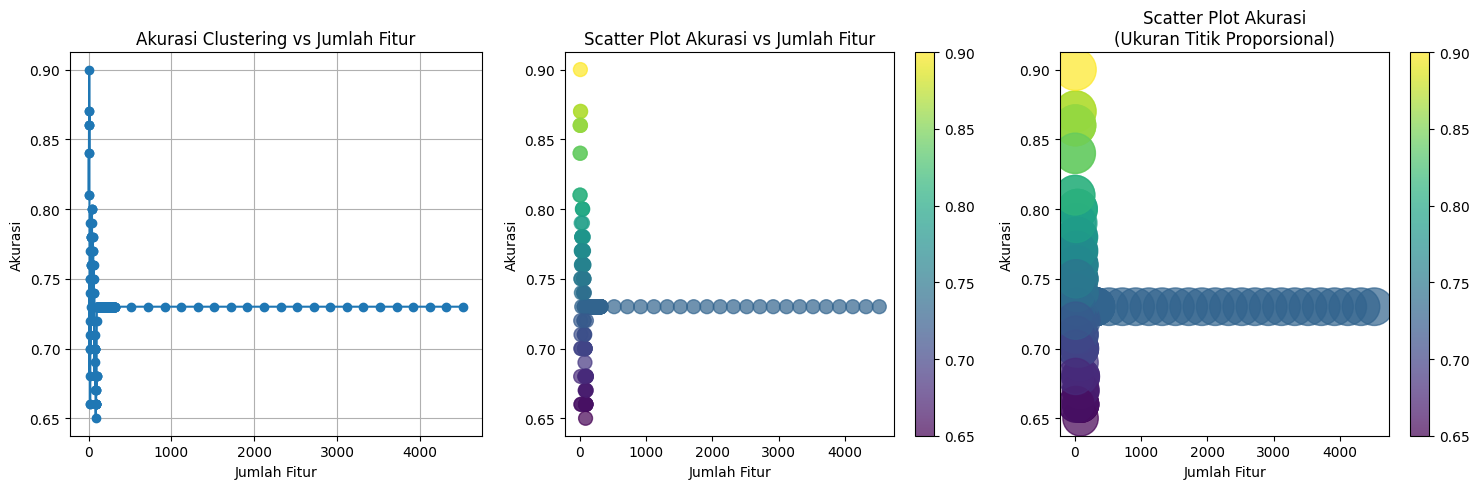


Jumlah fitur terbaik: 8
Akurasi terbaik: 0.9000


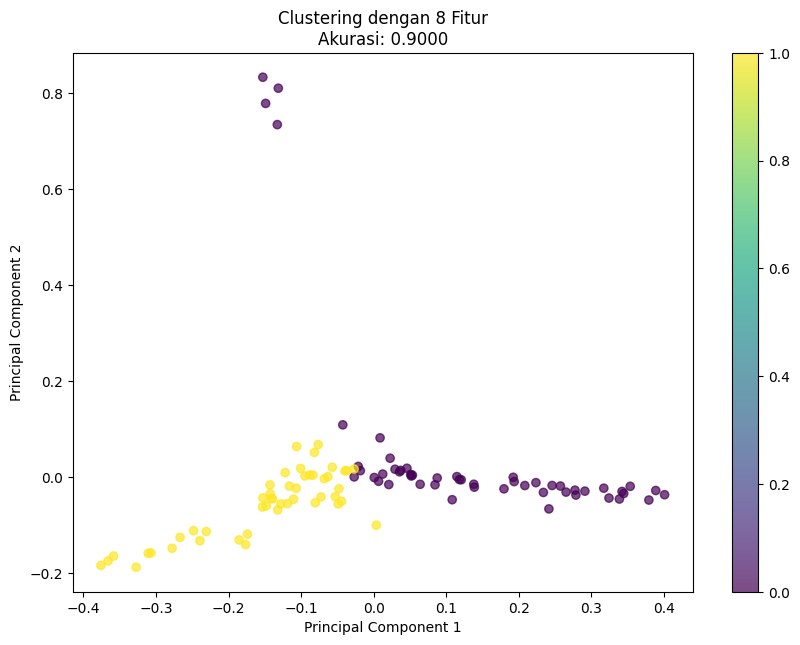


Tabel Hasil Reduksi Fitur:
     Jumlah Fitur  Akurasi
0            4517     0.73
1            4317     0.73
2            4117     0.73
3            3917     0.73
4            3717     0.73
..            ...      ...
332             6     0.86
333             5     0.86
334             4     0.81
335             3     0.84
336             2     0.81

[337 rows x 2 columns]


In [56]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan data
def clean_data(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    return matrix

# Fungsi untuk melakukan clustering dan evaluasi
def evaluate_clustering(data_features, true_labels, n_clusters=2):
    try:
        # Membersihkan data sebelum clustering
        data_features = clean_data(data_features)
        
        # Menjalankan Fuzzy C-Means
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            data_features.T, n_clusters, m=2, error=0.05, maxiter=1000, init=None, seed=42
        )
        
        # Menentukan kluster akhir
        cluster_labels = np.argmax(u, axis=0)
        
        # Mengonversi label true ke numerik jika belum
        label_encoder = LabelEncoder()
        true_labels_encoded = label_encoder.fit_transform(true_labels)
        
        # Menghitung akurasi
        akurasi = accuracy_score(true_labels_encoded, cluster_labels)
        
        return akurasi, cluster_labels
    except Exception as e:
        print(f"Error dalam clustering: {e}")
        return None, None

def reduce_features_and_evaluate(tfidf_matrix, true_labels, 
                                 max_features=None, 
                                 min_components=2, 
                                 component_reduction=200):  # Tambahkan parameter component_reduction
    # Jika max_features tidak ditentukan, gunakan jumlah fitur asli
    if max_features is None:
        max_features = tfidf_matrix.shape[1]
    
    # Daftar untuk menyimpan hasil
    feature_counts = []
    accuracies = []
    all_cluster_labels = []
    
    # Konversi sparse matrix ke dense dan bersihkan
    tfidf_matrix_dense = clean_data(tfidf_matrix.toarray())
    
    # Tahap 1: Reduksi cepat ke 500 fitur
    current_features = max_features
    while current_features > 500:
        try:
            # Reduksi dimensi dengan SVD
            svd = TruncatedSVD(
                n_components=min(current_features, tfidf_matrix_dense.shape[1]-1), 
                random_state=42
            )
            svd_matrix = clean_data(svd.fit_transform(tfidf_matrix_dense))
            
            # Evaluasi clustering
            akurasi, cluster_labels = evaluate_clustering(svd_matrix, true_labels)
            
            # Jika clustering berhasil
            if akurasi is not None:
                feature_counts.append(current_features)
                accuracies.append(akurasi)
                all_cluster_labels.append(cluster_labels)
                
                print(f"Fitur: {current_features}, Akurasi: {akurasi:.4f}")
            
            # Kurangi jumlah fitur secara signifikan
            current_features -= component_reduction
            
        except Exception as e:
            print(f"Terjadi kesalahan dengan {current_features} fitur: {e}")
            current_features -= component_reduction
            continue
    
    # Tahap 2: Reduksi perlahan dari 500 ke 2
    while current_features >= min_components:
        try:
            # Reduksi dimensi dengan SVD
            svd = TruncatedSVD(
                n_components=min(current_features, tfidf_matrix_dense.shape[1]-1), 
                random_state=42
            )
            svd_matrix = clean_data(svd.fit_transform(tfidf_matrix_dense))
            
            # Evaluasi clustering
            akurasi, cluster_labels = evaluate_clustering(svd_matrix, true_labels)
            
            # Jika clustering berhasil
            if akurasi is not None:
                feature_counts.append(current_features)
                accuracies.append(akurasi)
                all_cluster_labels.append(cluster_labels)
                
                print(f"Fitur: {current_features}, Akurasi: {akurasi:.4f}")
            
            # Kurangi jumlah fitur satu per satu
            current_features -= 1
            
        except Exception as e:
            print(f"Terjadi kesalahan dengan {current_features} fitur: {e}")
            current_features -= 1
            continue
    
    return feature_counts, accuracies, all_cluster_labels


# Membaca Dataset
df = pd.read_csv("preprocessing-kompas.csv")

# Inisialisasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer(norm='l2')
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])

# Lakukan reduksi fitur dan evaluasi
feature_counts, accuracies, all_cluster_labels = reduce_features_and_evaluate(
    tfidf_matrix, 
    df['kategori'], 
    min_components=2,
    component_reduction=200  # Anda bisa sesuaikan jumlah pengurangan
)

# Siapkan plot dengan 3 subplot
plt.figure(figsize=(15, 5))

# 1. Plot Akurasi vs Jumlah Fitur (Line Plot)
plt.subplot(1, 3, 1)
plt.plot(feature_counts, accuracies, marker='o')
plt.title('Akurasi Clustering vs Jumlah Fitur')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')
plt.grid(True)

# 2. Scatter Plot Akurasi vs Jumlah Fitur
plt.subplot(1, 3, 2)
scatter = plt.scatter(feature_counts, accuracies, 
                      c=accuracies, 
                      cmap='viridis', 
                      s=100, 
                      alpha=0.7)
plt.colorbar(scatter)
plt.title('Scatter Plot Akurasi vs Jumlah Fitur')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')

# 3. Scatter Plot dengan Ukuran Proporional pada Akurasi
plt.subplot(1, 3, 3)
sizes = [(acc * 1000) for acc in accuracies]  # Skala ukuran titik
scatter = plt.scatter(feature_counts, accuracies, 
                      c=accuracies, 
                      s=sizes, 
                      cmap='viridis', 
                      alpha=0.7)
plt.colorbar(scatter)
plt.title('Scatter Plot Akurasi\n(Ukuran Titik Proporsional)')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')

plt.tight_layout()
plt.show()

# Temukan indeks akurasi tertinggi
best_index = accuracies.index(max(accuracies))
best_features = feature_counts[best_index]
best_cluster_labels = all_cluster_labels[best_index]

print(f"\nJumlah fitur terbaik: {best_features}")
print(f"Akurasi terbaik: {accuracies[best_index]:.4f}")

# Visualisasi kluster terbaik dengan PCA
from sklearn.decomposition import PCA

# Konversi sparse matrix ke dense dan bersihkan
tfidf_matrix_dense = clean_data(tfidf_matrix.toarray())

# Reduksi dimensi untuk visualisasi
pca = PCA(n_components=2)
svd = TruncatedSVD(n_components=best_features, random_state=42)
svd_matrix = clean_data(svd.fit_transform(tfidf_matrix_dense))
pca_result = pca.fit_transform(svd_matrix)

# Plot scatter dengan warna kluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                      c=best_cluster_labels, 
                      cmap='viridis', 
                      alpha=0.7)
plt.colorbar(scatter)
plt.title(f'Clustering dengan {best_features} Fitur\nAkurasi: {accuracies[best_index]:.4f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Tambahan: Tabel hasil untuk referensi
hasil_df = pd.DataFrame({
    'Jumlah Fitur': feature_counts,
    'Akurasi': accuracies
})
print("\nTabel Hasil Reduksi Fitur:")
print(hasil_df)

## Link App Clustering dengan Fuzzy C-Means :
### https://huggingface.co/spaces/Raflyyy/Clustering_News